# Union de todos los datasets a uno solo

In [4]:
import pandas as pd
import numpy as np
import os

# Configuración de carpetas y archivos
carpeta_datos = 'Datasets'
archivos = {
    'PRECIP': os.path.join(carpeta_datos, '25015-CULIACAN (DGE)-SIN-Precip.csv'),
    'EVAP':   os.path.join(carpeta_datos, '25015-CULIACAN (DGE)-SIN-Evap.csv'),
    'TMAX':   os.path.join(carpeta_datos, '25015-CULIACAN (DGE)-SIN-Tmax.csv'),
    'TMIN':   os.path.join(carpeta_datos, '25015-CULIACAN (DGE)-SIN-Tmin.csv')
}

# Texto del encabezado exactamente igual al formato de BAdiraguato
encabezado_texto = """CNA-SMN-CG-GMC-SMAA-CLIMATOLOGIA
BASE DE DATOS CLIMATOLOGICA
 
ESTACION  : 25015
NOMBRE    : CULIACAN (DGE)
ESTADO    : SINALOA
MUNICIPIO : CULIACAN
SITUACIÓN : OPERANDO
ORGANISMO : CONAGUA-DGE
CVE-OMM   : Nulo
LATITUD   : 024.792°
LONGITUD  : -107.390°
ALTITUD   : 39 m
 
           PRECIP  EVAP   TMAX   TMIN
  FECHA     (MM)   (MM)   (°C)   (°C)
"""

def cargar_y_limpiar(ruta_archivo, nombre_variable):
    if not os.path.exists(ruta_archivo):
        print(f"No se encontró: {ruta_archivo}")
        return pd.DataFrame(columns=['FECHA', nombre_variable])
    
    df = pd.read_csv(ruta_archivo, skiprows=7)
    df['FECHA'] = (df['Día'].astype(str).str.zfill(2) + '/' + 
                   df['Mes'].astype(str).str.zfill(2) + '/' + 
                   df['Anio'].astype(str))
    df = df.rename(columns={'Datos': nombre_variable})
    return df[['FECHA', nombre_variable]]

# Cargamos y unimos
df_precip = cargar_y_limpiar(archivos['PRECIP'], 'PRECIP')
df_evap = cargar_y_limpiar(archivos['EVAP'], 'EVAP')
df_tmax = cargar_y_limpiar(archivos['TMAX'], 'TMAX')
df_tmin = cargar_y_limpiar(archivos['TMIN'], 'TMIN')

df_final = df_precip.merge(df_evap, on='FECHA', how='outer')
df_final = df_final.merge(df_tmax, on='FECHA', how='outer')
df_final = df_final.merge(df_tmin, on='FECHA', how='outer')

# Ordenar por fecha cronológicamente
df_final['temp_date'] = pd.to_datetime(df_final['FECHA'], format='%d/%m/%Y', errors='coerce')
df_final = df_final.sort_values('temp_date').drop(columns=['temp_date'])

# Reemplazar vacíos por "Nulo"
df_final = df_final.fillna('Nulo')

# Guardar como archivo de texto (.txt) con encabezado
nombre_salida = './Datasets/25015_CULIACAN_DGE_1961_a_2016.csv'

with open(nombre_salida, 'w', encoding='utf-8') as f:
    f.write(encabezado_texto)
    # Escribimos los datos línea por línea con espaciado similar al original
    for _, row in df_final.iterrows():
        linea = f"{row['FECHA']}  {str(row['PRECIP']).ljust(6)}  {str(row['EVAP']).ljust(6)}  {str(row['TMAX']).ljust(6)}  {str(row['TMIN']).ljust(6)}\n"
        f.write(linea)

print(f"✅ Proceso completado. Archivo generado: {nombre_salida}")

✅ Proceso completado. Archivo generado: ./Datasets/25015_CULIACAN_DGE_1961_a_2016.csv


# Exploracion de la estructura de los datos.
Lo primero que hicimos fue analizar y explorar los datos y la estructura del archivo mediante diferentes funciones de la libreria pandas.  

**Funciones y atributos utilizados:**  
**1.-read_csv:** Lectura del archivo mediante pandas.  
**2.- Skiprows:** Realiza saltos de linea del archivo. Lo utilizamos ya que las primeras lineas del txt tienen informacion adicional al Data Frame. Los registros comienzan en la linea 20.  
**3.- Skipfooter:** Al contrario de skiprows, skipfooter hace los saltos empezando de la ultima linea del archivo. Lo utilizamos ya que el ultimo registro tiene guiones en vez de datos.  
**4.- Names:** Mediante una lista asigna los nombres de las columnas.  
**5.- Sep:** Se utiliza para definir un delimitador entre columnas. Lo utilizamos ya que pandas tomaba las columnas de names como columnas independientes y les asignaba nulos a todos los registros. r (raw) indica que debe tomar todos los caracteres como datos, \s+ es para los espacios en blanco.  
**6.-na_values** Sirve para indicar que una cadena es de tipo NaN. Le indicamos que los registros con el dato 'Nulo' contaran como nules. Esto solo para el analisis del archivo por lo que no modifica el dataframe.  
**7.- info():** Muestra un resumen del dataframe. Datos como el numero de registros, nombres de columna, tipos de dato, cantidad de nulos etc.  
**8.- shape:** Devuelve una tupla con las dimensiones del data frame (numero de filas y columnas).  
**9.- head():** Regresa las primeras filas del data frame.  
**10.- tail():** Muestra las ultimas filas del data frame.  
**11.- isnull().sum():** Hace la suma de todos los nulos por cada columna tambien muestra tipo de dato.  
**12.- nunique():** Devuelve la cantidad de registors unicos por cada columna.  


Lectura de archivos mediante pandas:

In [6]:
#Importacion de pandas y lectura del archivo.
import pandas as pd
df=pd.read_csv('Datasets/25015_CULIACAN_DGE_1961_a_2016.csv',
skiprows=16, #saltamos las primeras 18 lineas del archivo
names=['FECHA','PRECIP','EVAP','TMAX','TMIN'] , #Nombres de las columnas 
sep=r'\s+',#Separamos las columnas correctamente 
na_values='Nulo', #Asignamos como nulos los datos que contengan 'Nulo'
) 
df

,FECHA,PRECIP,EVAP,TMAX,TMIN
0,01/01/1961,0.0,2.90,22.0,10.5
1,02/01/1961,0.0,2.70,25.0,9.0
2,03/01/1961,0.0,3.70,29.0,10.0
3,04/01/1961,0.0,2.50,22.0,13.0
4,05/01/1961,0.0,1.10,24.0,14.0
...,...,...,...,...,...
20235,27/05/2016,0.0,4.89,39.5,21.5
20236,28/05/2016,0.0,9.27,39.5,19.5
20237,29/05/2016,0.0,8.77,39.5,20.0
20238,30/05/2016,2.3,6.75,35.0,22.5


El Data Frame tiene un total 19574 registros, 5 columnas (FECHA, PRECIP, EVAP, TMAX Y TMIN todas de tipo String). 

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20240 entries, 0 to 20239
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   FECHA   20240 non-null  object 
 1   PRECIP  20173 non-null  float64
 2   EVAP    19867 non-null  float64
 3   TMAX    20127 non-null  float64
 4   TMIN    20116 non-null  float64
dtypes: float64(4), object(1)
memory usage: 790.8+ KB


In [8]:
df.shape

(20240, 5)

**Cada columna esta compuesta por:**  
**1.-Fecha:** fecha en dia, mes y año de la muestra.  
**2.-Precip:** precipitacion en milimietros de la muestra.  
**3.-Evap:** evaporacion en milimietros de la muestra.  
**4.-TMAX:** temperatura maxima en grados celsius de la muestra.  
**5.-TMIN** temperatura minima en grados celcius de la muestra.  


Las primeras 10 columnas muestran una precipitacion de 0, evaporacion en nulos, TMAX y TMIN muestran la temperatura maxima y minima en la fecha correspondiente.

In [9]:
df.head(10)

,FECHA,PRECIP,EVAP,TMAX,TMIN
0,01/01/1961,0.0,2.9,22.0,10.5
1,02/01/1961,0.0,2.7,25.0,9.0
2,03/01/1961,0.0,3.7,29.0,10.0
3,04/01/1961,0.0,2.5,22.0,13.0
4,05/01/1961,0.0,1.1,24.0,14.0
5,06/01/1961,0.0,1.9,22.0,13.0
6,07/01/1961,0.0,4.0,24.0,8.0
7,08/01/1961,0.0,6.3,30.0,9.0
8,09/01/1961,0.0,5.2,31.0,14.0
9,10/01/1961,0.0,3.6,30.0,10.0


A diferencia de los primeros 10 registros, los ultimos 10 si cuentan con una precipitacion y evaporacion ademas de la temperatura maxima y minima.

In [10]:
df.tail(10)

,FECHA,PRECIP,EVAP,TMAX,TMIN
20230,22/05/2016,0.0,8.91,37.5,21.0
20231,23/05/2016,0.0,7.19,38.0,19.0
20232,24/05/2016,0.0,6.99,36.0,21.0
20233,25/05/2016,0.0,6.27,33.0,25.0
20234,26/05/2016,0.0,1.85,37.5,24.5
20235,27/05/2016,0.0,4.89,39.5,21.5
20236,28/05/2016,0.0,9.27,39.5,19.5
20237,29/05/2016,0.0,8.77,39.5,20.0
20238,30/05/2016,2.3,6.75,35.0,22.5
20239,31/05/2016,0.0,1.18,34.5,24.0


In [11]:
df.isnull().sum()

FECHA       0
PRECIP     67
EVAP      373
TMAX      113
TMIN      124
dtype: int64

El data frame cuenta con 19574 registros. **Fecha tiene todos sus registros unicos** esto significa que no existen fechas repetidas.

In [12]:
df.nunique()

FECHA     20240
PRECIP      476
EVAP       1131
TMAX         68
TMIN         57
dtype: int64

## Contabilizar numero de datos faltantes por fecha.  
Funciones y atributos utilizados:  
**1.-to_datetime():** Esta funcion convierte el tipo de dato a datetime.  
**2.-dayfirst:** Este atributo indica que el formato de la fecha es dia/mes/año. Lo utilizamos por que ese es el formato que tiene el archivo.  
**3.-dt.date:** Toma solamente la fecha del datetime dejando fuera la hora. Lo utilizamos por que no necesitamos la hora para contabilizar los dias faltantes.  
**4.-.loc:** Toma un registro determinado mediante fila-columna.  
**5.-date_range():** Crea un rango de fechas.   
**6.-difference():** Compara elementos entre dos series y guarda los elementos diferentes en otra serie.  


Lo primero que hicimos fue cambiar el tipo de dato de la columna fecha a date. Como date_time nos da el formato dia-mes-año hora:minuto:segundo utilizamos dt.date para solo obtener la fecha sin la hora.  
Despues inicializamos el rango de fechas que tiene el dataframe con date range y las fechas de inicio y final y una frecuendia en dias.  
A continuacion comparamos el rango completo con las fechas existentes en el dataframe y lo guardamos en fechas faltantes para despues imprimirlo.



In [14]:
def dias_faltantes(df):
    
    df['FECHA'] = pd.to_datetime(df['FECHA'],dayfirst=True)#Conversion de columna FECHA a datetime
    df['FECHA'] = df['FECHA'].dt.date #Tomamos solamente la fecha
    #Tomamos el rango de fechas del dataframe 1961-01-01 a 2018-07-31
    inicio=df.loc[0,'FECHA'] 
    final=df.loc[df.index[-1],'FECHA'] #.index[-1] para tomar el ultimo elemento de la columna
    rango_completo = pd.date_range(start=inicio, end=final, freq='D')
    fechas_faltantes = rango_completo.difference(df['FECHA'])
    print(f"Dias faltantes entre {inicio} y {final}: {len(fechas_faltantes)}")

#Ejecucion del metodo
dias_faltantes(df)

Dias faltantes entre 1961-01-01 y 2016-05-31: 0


### ¿Cuántos datos nos faltan por cada año?
Antes de rellenar los espacios nulos, es muy importante saber en qué años la estación de Acatitán dejó de reportar datos. Esto nos ayuda a ver si la falta de información es algo de un solo año o si es constante.

In [16]:
def contar_nulos_por_anio(df_temp):
    """
    Función para contar cuántos datos faltan en cada columna, 
    separados por cada año del registro.
    """
    # Convertimos la columna de fecha a formato datetime, indicando que el día se muestra antes que el mes con el parámetro (dayfirst=True)
    df_temp['FECHA'] = pd.to_datetime(df_temp['FECHA'], dayfirst=True)

    # Creamos la columna 'Año' extrayendo el año de la columna 'FECHA'
    df_temp['Año'] = df_temp['FECHA'].dt.year

    # Definimos las columnas numéricas que queremos analizar
    cols_clima = ['PRECIP', 'EVAP', 'TMAX', 'TMIN']

    # Calculamos los nulos por año
    # isnull() crea True/False, al agrupar por 'Año' y usar .sum(), contamos cuántos True (nulos) hay por cada año
    nulos_por_anio = df[cols_clima].isnull().groupby(df['Año']).sum()

    # Mostramos el resultado de manera clara 
    print("--- Cantidad de datos nulos detectados por Año ---")
    display(nulos_por_anio)

    # Opcional: Ver el total general de nulos antes de proceder
    print("\nTotal de nulos en todo el registro:")
    print(df[cols_clima].isnull().sum())

    return df_temp

# Se manda a llamar la función
df = contar_nulos_por_anio(df)

--- Cantidad de datos nulos detectados por Año ---


,PRECIP,EVAP,TMAX,TMIN
Año,,,,
1961,0,0,0,0
1962,0,1,0,0
1963,0,12,9,8
1964,0,27,10,11
1965,0,1,0,0
1966,0,0,0,0
1967,2,0,0,0
1968,0,1,0,0
1969,2,0,18,29



Total de nulos en todo el registro:
PRECIP     67
EVAP      373
TMAX      113
TMIN      124
dtype: int64


# Proceso de Transformación y Limpieza de Datos
En esta etapa, convertimos los datos crudos en un formato apto para el análisis estadístico. El proceso se ha dividido en funciones específicas que permiten un manejo controlado de la información.

### Librerías y Métodos Utilizados:
* **Pandas:** Utilizada para la estructuración y limpieza del DataFrame.
* **to_datetime (errors='coerce'):** Transforma la columna de fechas. El uso de `coerce` es fundamental para la **limpieza**, ya que convierte automáticamente cualquier texto inválido (como títulos o guiones) en valores `NaT` (Not a Time), evitando errores de ejecución.
* **dropna():** Elimina las filas que no contienen fechas válidas, asegurando que solo trabajemos con registros cronológicos reales.
* **to_numeric:** Convierte las columnas de medición (Precipitación, Evaporación, etc.) de texto a números decimales para permitir el cálculo de métricas.

In [17]:
def transformar_datos(df_temp):
    """
    Función modular para convertir tipos de datos y eliminar basura de texto.
    """
    # Convertimos la columna de fecha a formato datetime, indicando que el día se muestra antes que el mes con el parámetro (dayfirst=True)
    df_temp['FECHA'] = pd.to_datetime(df_temp['FECHA'], dayfirst=True)

    # Convertimos las columnas de datos a números 
    cols_num = ['PRECIP', 'EVAP', 'TMAX', 'TMIN']
    df_temp[cols_num] = df_temp[cols_num].apply(pd.to_numeric) # Convertimos a datos númericos usando apply() para aplicar la función a cada columna
    
    return df_temp

# Llamada a la función
df = transformar_datos(df)
df.head()

,FECHA,PRECIP,EVAP,TMAX,TMIN,Año
0,1961-01-01,0.0,2.9,22.0,10.5,1961
1,1961-01-02,0.0,2.7,25.0,9.0,1961
2,1961-01-03,0.0,3.7,29.0,10.0,1961
3,1961-01-04,0.0,2.5,22.0,13.0,1961
4,1961-01-05,0.0,1.1,24.0,14.0,1961


### Tratamiento de Valores Faltantes (Nulos)
Para garantizar la integridad del Análisis Exploratorio de Datos (EDA), es necesario tratar los valores nulos identificados previamente. Rellenamos los datos faltantes con la media

In [18]:
def aplicar_limpieza_nulos(df_temp):
    """
    Rellena los espacios vacíos con el promedio de la columna.
    """
    cols_num = ['PRECIP', 'EVAP', 'TMAX', 'TMIN']
    
    # Rellenamos nulos con la media de cada columna 
    df_temp[cols_num] = df_temp[cols_num].fillna(df_temp[cols_num].mean())
    
    return df_temp

# Aplicamos la limpieza
df = aplicar_limpieza_nulos(df)
# Verificamos que ya no existan nulos
df.isnull().sum()

FECHA     0
PRECIP    0
EVAP      0
TMAX      0
TMIN      0
Año       0
dtype: int64

# Análisis Exploratorio de Datos final
En esta sección final, generamos las métricas estadísticas que solicita la rúbrica. El objetivo es identificar los valores máximos, mínimos, la media y la mediana de las variables climáticas registradas en la estación.

**Funciones Utilizadas:**
* **describe():** Para obtener un panorama estadístico global.
* **mean(), median(), max(), min():** Para cumplir con la identificación específica de métricas requeridas en el proyecto.

In [19]:
def ejecutar_eda(df_temp):
    """
    Calcula y muestra las estadísticas principales del dataset.
    """
    # Elegimos las columnas a utilizar para calcular los datos
    cols_num = ['PRECIP', 'EVAP', 'TMAX', 'TMIN']
    
    print("--- RESUMEN ESTADÍSTICO ---")
    # Se muestra el resumen estadístico general de las columnas numéricas
    display(df_temp[cols_num].describe())
    
    print("\n--- MÉTRICAS ESPECÍFICAS SOLICITADAS ---")
    # Creamos un DataFrame para mostrar las métricas específicas de media, mediana, máximo y mínimo
    stats_resumen = pd.DataFrame({
        'Media (Promedio)': df_temp[cols_num].mean(), # Calculamos la media de cada columna numérica
        'Mediana': df_temp[cols_num].median(), # Calculamos la mediana de cada columna numérica
        'Valor máximo': df_temp[cols_num].max(), # Calculamos el valor máximo de cada columna numérica
        'Valor mínimo': df_temp[cols_num].min() # Calculamos el valor mínimo de cada columna numérica
    })
    display(stats_resumen)

# Ejecutamos el análisis final
ejecutar_eda(df)

--- RESUMEN ESTADÍSTICO ---


,PRECIP,EVAP,TMAX,TMIN
count,20240.000000,20240.000000,20240.000000,20240.000000
mean,1.843900,5.816629,32.584056,17.704931
std,8.256141,2.390608,4.034778,5.725352
min,0.000000,0.010000,14.000000,2.000000
25%,0.000000,4.050000,30.000000,13.000000
50%,0.000000,5.650000,33.000000,17.500000
75%,0.000000,7.550000,35.500000,23.000000
max,258.000000,17.900000,46.000000,29.500000



--- MÉTRICAS ESPECÍFICAS SOLICITADAS ---


,Media (Promedio),Mediana,Valor máximo,Valor mínimo
PRECIP,1.843900,0.00,258.0,0.00
EVAP,5.816629,5.65,17.9,0.01
TMAX,32.584056,33.00,46.0,14.00
TMIN,17.704931,17.50,29.5,2.00


# Visualización de los resultados
Para terminar con el análisis exploratorio, vamos a crear gráficas sencillas que nos ayuden a ver cómo se comportan las temperaturas y la lluvia en Acatitán. 

**Gráficas que vamos a generar:**
1. **Histogramas:** Para ver qué tan seguido se repiten ciertas temperaturas.
2. **Gráfica de líneas:** Para observar cómo cambia la temperatura a lo largo del tiempo.

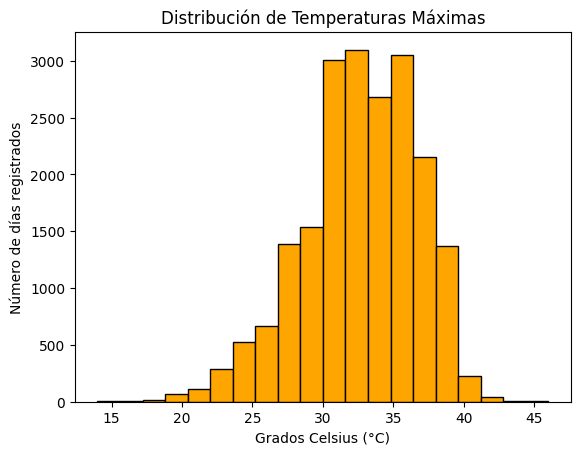

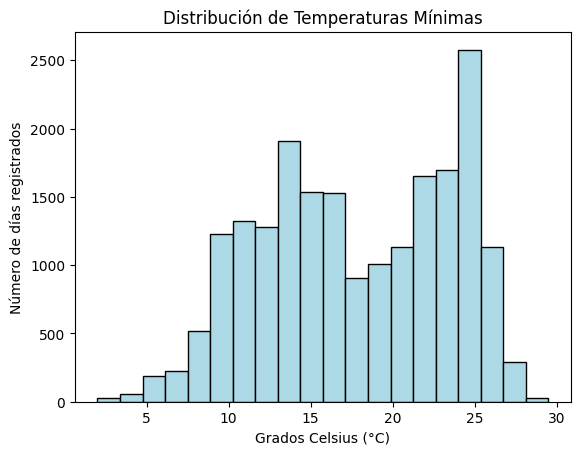

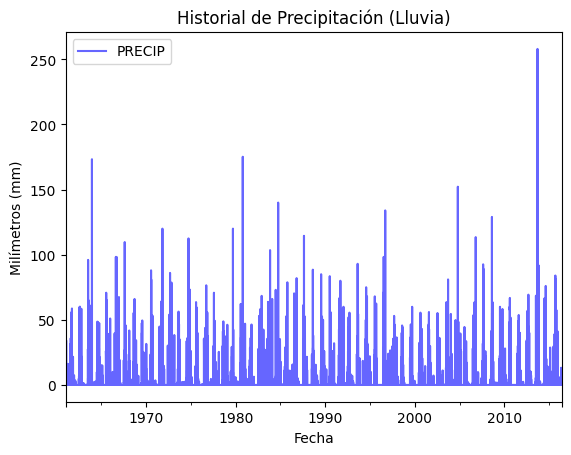

In [20]:
import matplotlib.pyplot as plt

def graficar_datos(df_temp):
    """
    Crea gráficas básicas para entender mejor visualmente los resultados de los datos del clima.
    """
    # Histograma de Temperaturas Máximas
    # Esta gráfica nos dice en qué rango de grados máximos se mantiene la temperatura en la estación
    # bins nos sirve para decidir cuántas barras queremos ver
    # edgecolor nos ayuda a resaltar el contorno de cada barra del histograma para una mejor visualización
    df_temp['TMAX'].plot(kind='hist', bins= 20,color='orange', edgecolor='black') 
    plt.title('Distribución de Temperaturas Máximas')
    plt.xlabel('Grados Celsius (°C)')
    plt.ylabel('Número de días registrados')
    plt.show()

    # Histograma de Temperaturas Mínimas
    # Esta gráfica nos dice en qué rango de grados mínimos se mantiene la temperatura en la estación
    df_temp['TMIN'].plot(kind='hist', bins=20, color='lightblue', edgecolor='black') 
    plt.title('Distribución de Temperaturas Mínimas')
    plt.xlabel('Grados Celsius (°C)')
    plt.ylabel('Número de días registrados')
    plt.show()

    # Gráfica de Lluvia (Precipitación)
    # Usamos una gráfica de líneas para ver la probabilidad de lluvia en base a la fecha
    df_temp.plot(x='FECHA', y='PRECIP', color='blue', alpha=0.6) # El parametro alpha sirve para dar transparencia a la gráfica
    plt.title('Historial de Precipitación (Lluvia)')
    plt.xlabel('Fecha')
    plt.ylabel('Milímetros (mm)')
    plt.show()

# Ejecutamos las gráficas 
graficar_datos(df)